In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [4]:
def basic_exploration(df):
    print("First 5 rows:")
    display(df.head())

    print("\nShape of dataset:")
    print(df.shape)

    print("\nDataset information:")
    df.info()

    print("\nStatistical summary:")
    display(df.describe(include="all"))

    print("\nMissing values:")
    display(df.isnull().sum())

In [5]:
titanic = sns.load_dataset("titanic")
basic_exploration(titanic)

First 5 rows:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True



Shape of dataset:
(891, 15)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB

Statistical summary:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Missing values:


survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

## Find How Many Passengers Survived and Did Not Survive

survived
0    549
1    342
Name: count, dtype: int64


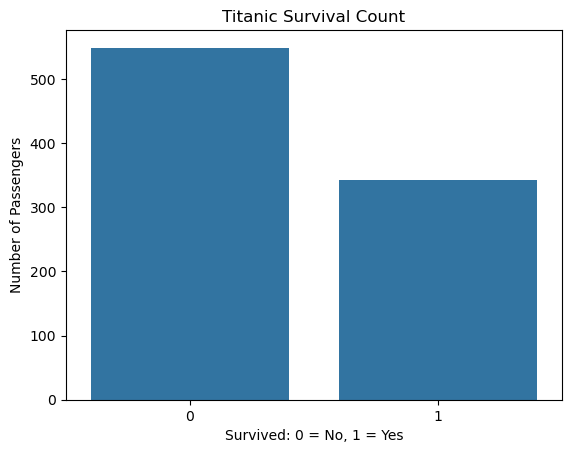

In [8]:
print(titanic["survived"].value_counts())

sns.countplot(data=titanic, x="survived")
plt.title("Titanic Survival Count")
plt.xlabel("Survived: 0 = No, 1 = Yes")
plt.ylabel("Number of Passengers")
plt.show()

## Observation: The number of non-survivors is higher than the number of survivors.

## Compare Survival Based on Gender

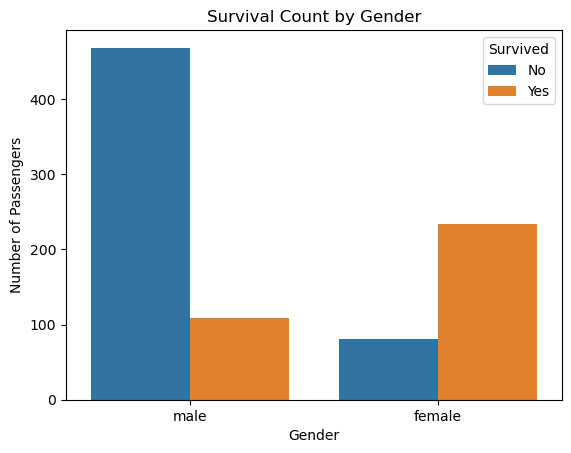

Survival percentage by gender:
sex
female    74.203822
male      18.890815
Name: survived, dtype: float64


In [9]:
sns.countplot(data=titanic, x="sex", hue="survived")
plt.title("Survival Count by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")
plt.legend(title="Survived", labels=["No", "Yes"])
plt.show()

survival_by_gender = titanic.groupby("sex")["survived"].mean() * 100
print("Survival percentage by gender:")
print(survival_by_gender)

## Observation: Female passengers had a much higher survival rate than male passengers

## Compare Survival Based on Passenger Class

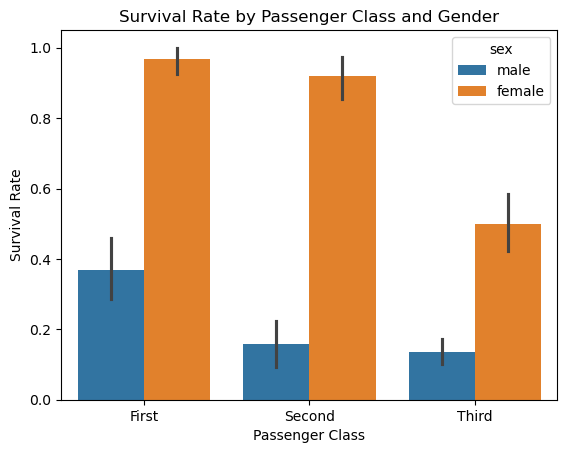

Survival percentage by passenger class:
class
First     62.962963
Second    47.282609
Third     24.236253
Name: survived, dtype: float64


In [10]:
sns.barplot(data=titanic, x="class", y="survived", hue="sex")
plt.title("Survival Rate by Passenger Class and Gender")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.show()

class_survival = titanic.groupby("class", observed=True)["survived"].mean() * 100
print("Survival percentage by passenger class:")
print(class_survival)

## Observation: First class passengers had the highest survival rate, followed by second class and third class.

## Show Age Distribution of Passengers

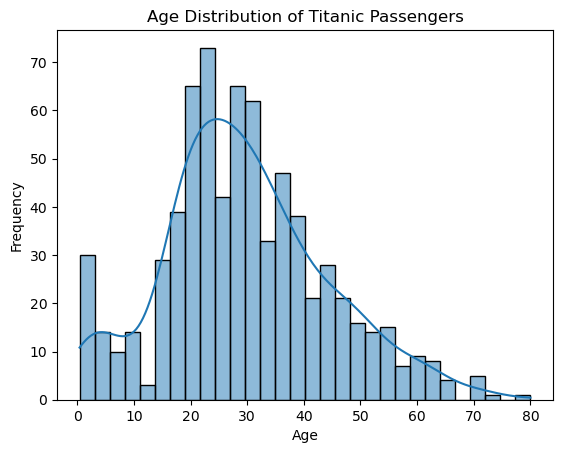

In [11]:
sns.histplot(data=titanic, x="age", bins=30, kde=True)
plt.title("Age Distribution of Titanic Passengers")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

## Observation: Most passengers were young adults. The age distribution shows many passengers between approximately 20 and 40 years.

## Analyze Fare and Age with Survival

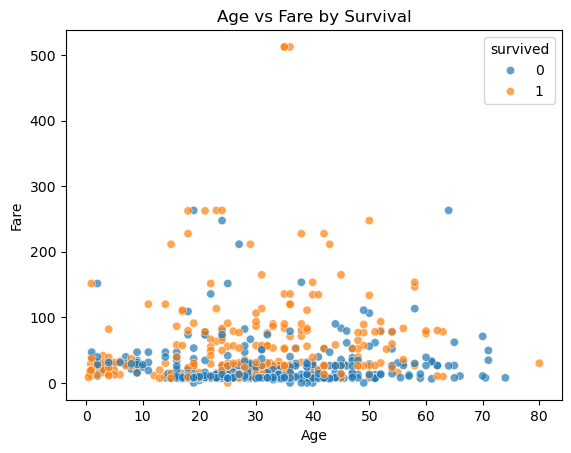

In [12]:
sns.scatterplot(data=titanic, x="age", y="fare", hue="survived", alpha=0.7)
plt.title("Age vs Fare by Survival")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()

## CONCLUSION: Female passengers and first class passengers had better survival chances. Age alone does not clearly determine survival, but fare and class seem related because passengers paying higher fares often belonged to higher classes.